# 01. Data Exploration & Universe Health
**Objective:** rigorous assessment of the master dataset's quality, breadth, and stationarity prior to alpha modeling.

### Institutional Quality Checks:
1. **Data Integrity:** Check for missing values, infinite values, and look-ahead bias artifacts.
2. **Universe Health:** Analyze liquidity coverage and sector breadth over time.
3. **Target Distribution:** Validate the stationarity and normality of the target variable (Sector-Neutral 5d Return).
4. **Feature Structure:** Examine correlation clusters to identify redundant information.

In [19]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path('../').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from config.settings import config
from quant_alpha.utils import setup_logging, load_parquet

setup_logging()
sns.set_style('darkgrid')
%matplotlib inline

## 1. Load Master Dataset

In [20]:
data_path = config.CACHE_DIR / 'master_data_with_factors.parquet'
if not data_path.exists():
    raise FileNotFoundError("Run scripts/update_data.py and scripts/train_models.py (step 1) to generate data.")

df = load_parquet(data_path)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['ticker', 'date']).reset_index(drop=True)

# FIX: Calculate target if missing (it is computed in pipeline, not saved in master_data)
if 'target' not in df.columns:
    print("⚠️ 'target' column missing. Calculating Sector-Neutral Return...")
    if 'raw_ret_5d' not in df.columns:
        if 'open' in df.columns:
            print("⚠️ 'raw_ret_5d' missing. Calculating from Open prices...")
            df['next_open'] = df.groupby('ticker')['open'].shift(-1)
            df['future_open'] = df.groupby('ticker')['open'].shift(-6)
            df['raw_ret_5d'] = (df['future_open'] / df['next_open']) - 1
        else:
            print("❌ 'open' column missing. Cannot calculate returns.")

    if 'raw_ret_5d' in df.columns and 'sector' in df.columns:
        sector_mean = df.groupby(['date', 'sector'], observed=False)['raw_ret_5d'].transform('mean')
        df['target'] = df['raw_ret_5d'] - sector_mean
    elif 'raw_ret_5d' in df.columns:
        print("⚠️ Sector missing. Using raw_ret_5d as target.")
        df['target'] = df['raw_ret_5d']
    else:
        print("❌ Could not create 'target' column.")

if 'target' in df.columns:
    df = df.dropna(subset=['target'])

print(f"Loaded {len(df):,} rows | {df['date'].min().date()} to {df['date'].max().date()}")

⚠️ 'target' column missing. Calculating Sector-Neutral Return...
Loaded 976,019 rows | 2016-01-04 to 2023-12-29


## 2. Universe Health (Ticker Count)

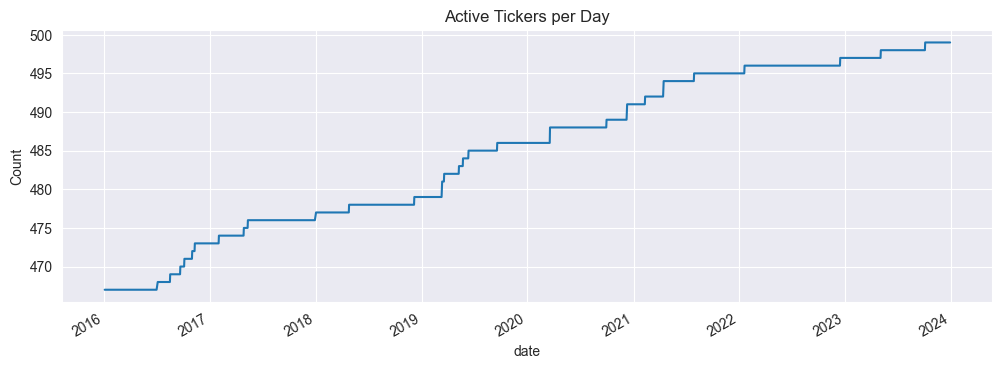

In [21]:
ticker_counts = df.groupby('date')['ticker'].nunique()
plt.figure(figsize=(12, 4))
ticker_counts.plot(title='Active Tickers per Day')
plt.ylabel('Count')
plt.show()

## 3. Target Distribution Analysis
We check `target` (Sector-Neutral 5d Return) for outliers and stationarity.

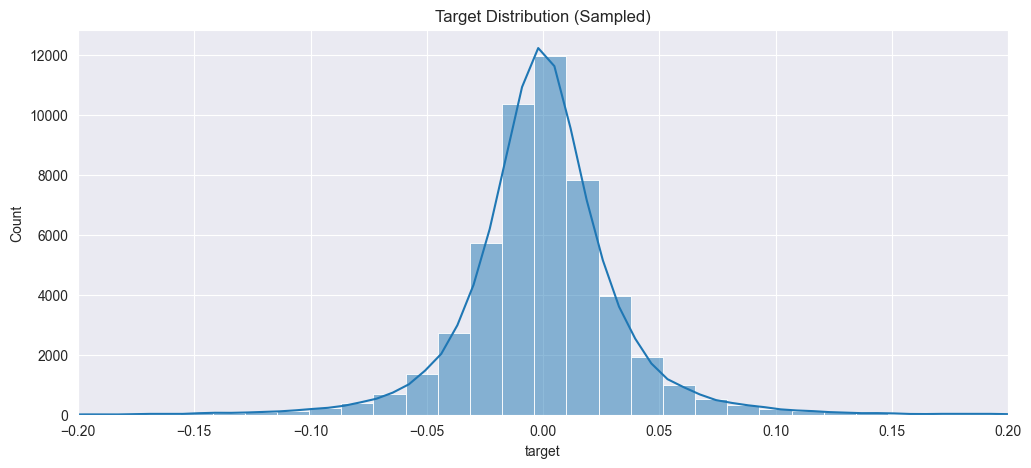

Target Mean: 0.000000
Target Std:  0.035173
Skewness:    0.8634


In [27]:
plt.figure(figsize=(12, 5))
sns.histplot(df['target'].sample(50000), bins=100, kde=True, label='Sector-Neutral Target')
plt.title('Target Distribution (Sampled)')
plt.xlim(-0.2, 0.2)
plt.show()

print(f"Target Mean: {df['target'].mean():.6f}")
print(f"Target Std:  {df['target'].std():.6f}")
print(f"Skewness:    {df['target'].skew():.4f}")

## 4. Feature Correlation Structure
Check correlation among a subset of technical and fundamental features.

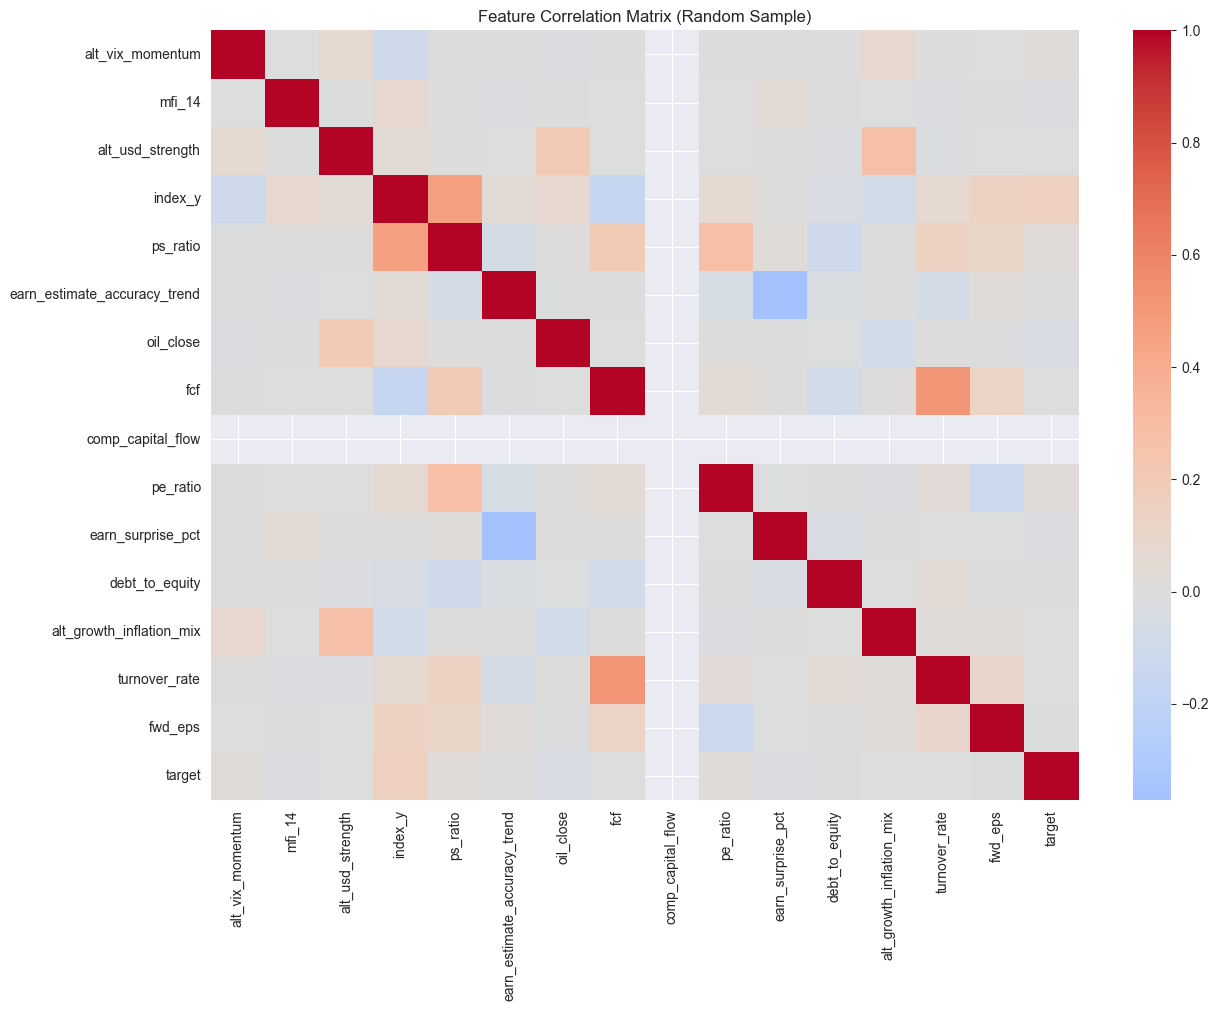

In [28]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
exclude = ['open', 'high', 'low', 'close', 'volume', 'target', 'raw_ret_5d', 'pnl_return']
features = [c for c in numeric_cols if c not in exclude]

# Sample 15 random features + target
if features:
    n_feat_sample = min(15, len(features))
    n_row_sample = min(10000, len(df))
    sample_feats = np.random.choice(features, n_feat_sample, replace=False).tolist()
    
    corr_df = df[sample_feats + ['target']].sample(n_row_sample).corr()

    plt.figure(figsize=(14, 10))
    sns.heatmap(corr_df, cmap='coolwarm', center=0, annot=False)
    plt.title('Feature Correlation Matrix (Random Sample)')
    plt.show()
else:
    print("⚠️ No features found for correlation analysis.")